## 13. Load data from Google Drive

In [1]:
# === Load from Google Drive ===
import pandas as pd
import joblib
from google.colab import drive

drive.mount('/content/drive')

# Load processed feature and label sets
X_train = pd.read_csv("/content/drive/MyDrive/X_train_processed.csv")
X_test = pd.read_csv("/content/drive/MyDrive/X_test_processed.csv")
y_train = pd.read_csv("/content/drive/MyDrive/y_train_processed.csv").squeeze()
y_test = pd.read_csv("/content/drive/MyDrive/y_test_processed.csv").squeeze()

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/standard_scaler.pkl")

# === Align test columns with train (important after one-hot encoding) ===
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

Mounted at /content/drive


## 14. Baseline Modeling on Preprocessed Data

Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

==== Final Test Set Evaluation ====


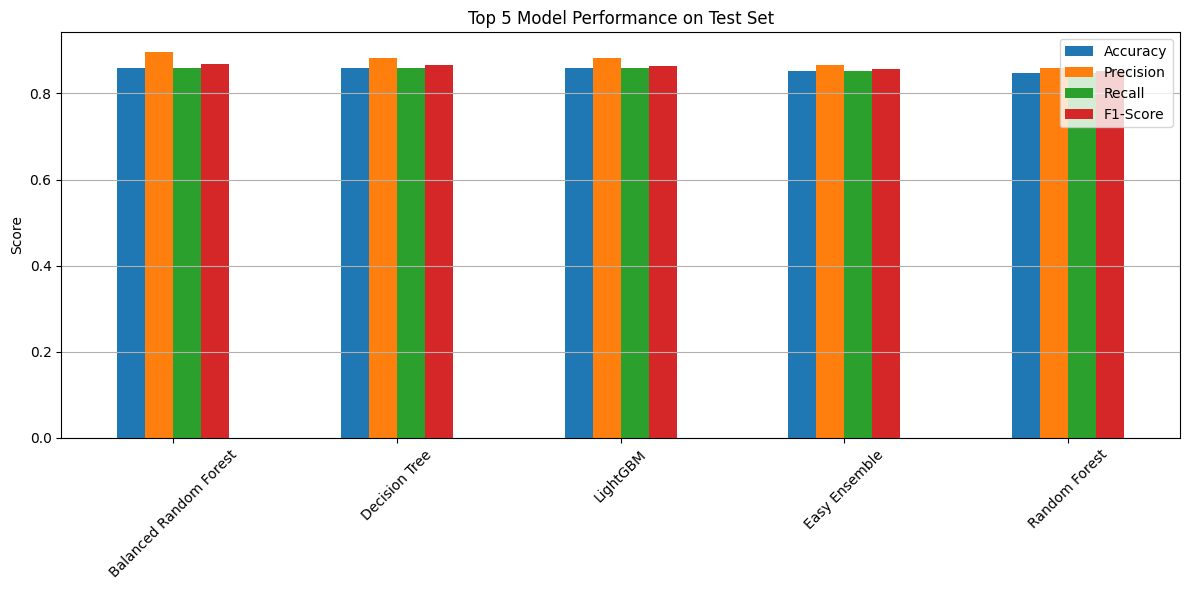

In [2]:
# === Modeling and Evaluation ===
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.ensemble import (
    BalancedRandomForestClassifier, EasyEnsembleClassifier
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== SET YOUR SAMPLING RATIO HERE ====
subset_ratio = 0.2  # use 20% of train/test data

# ==== Subsample X_train and y_train ====
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=subset_ratio, stratify=y_train, random_state=42
)

# ==== Subsample X_test and y_test ====
X_test_small, _, y_test_small, _ = train_test_split(
    X_test, y_test, train_size=subset_ratio, stratify=y_test, random_state=42
)

# ==== Use part of X_train_small for cross-validation ====
X_cv_sample, _, y_cv_sample, _ = train_test_split(
    X_train_small, y_train_small, train_size=subset_ratio, stratify=y_train_small, random_state=42
)

# ==== Define Stratified K-Fold and scoring ====
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1': make_scorer(f1_score, average='weighted', zero_division=0),
}

# ==== Define model groups ====
group1 = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=25, max_depth=10, n_jobs=-1, random_state=42),
}
group2 = {
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB()
}
group3 = {
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBClassifier(eval_metric="mlogloss", n_estimators=50, learning_rate=0.1, max_depth=3, n_jobs=-1, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=50, learning_rate=0.1, max_depth=10, random_state=42, verbose=-1, n_jobs=-1),
}
group4 = {
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    'Balanced Random Forest': BalancedRandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    'Easy Ensemble': EasyEnsembleClassifier(n_estimators=10, n_jobs=-1, random_state=42),
}
all_groups = [group1, group2, group3, group4]
all_results = []

# ==== Evaluation function ====
def evaluate_models(models, X, y, skf, scoring):
    results = {}
    for name, model in models.items():
        print(f"Evaluating {name}...")
        scores = cross_validate(model, X, y, cv=skf, scoring=scoring, return_train_score=False)
        results[name] = {
            'Accuracy': np.mean(scores['test_accuracy']),
            'Precision': np.mean(scores['test_precision']),
            'Recall': np.mean(scores['test_recall']),
            'F1-Score': np.mean(scores['test_f1']),
        }
    return pd.DataFrame(results).T

# ==== Run cross-validation ====
for i, group in enumerate(all_groups, 1):
    result = evaluate_models(group, X_cv_sample, y_cv_sample, skf, scoring)
    result.to_csv(f"results_group{i}.csv")
    all_results.append(result)

combined_results = pd.concat(all_results)
combined_results.to_csv("all_model_results.csv")

# ==== Final test set evaluation ====
print("\n==== Final Test Set Evaluation ====")
final_test_results = {}
for model_name in combined_results.index:
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            model.fit(X_train_small, y_train_small)
            y_pred = model.predict(X_test_small)
            final_test_results[model_name] = {
                'Accuracy': accuracy_score(y_test_small, y_pred),
                'Precision': precision_score(y_test_small, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test_small, y_pred, average='weighted', zero_division=0),
                'F1-Score': f1_score(y_test_small, y_pred, average='weighted', zero_division=0)
            }
            break

final_df = pd.DataFrame(final_test_results).T.sort_values(by='F1-Score', ascending=False)
final_df.to_csv("final_test_performance.csv")

# ==== Plot Top 5 ====
final_df.head(5).plot(kind='bar', figsize=(12, 6), title="Top 5 Model Performance on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Normalized Confusion Matrix for Top-Performing Models

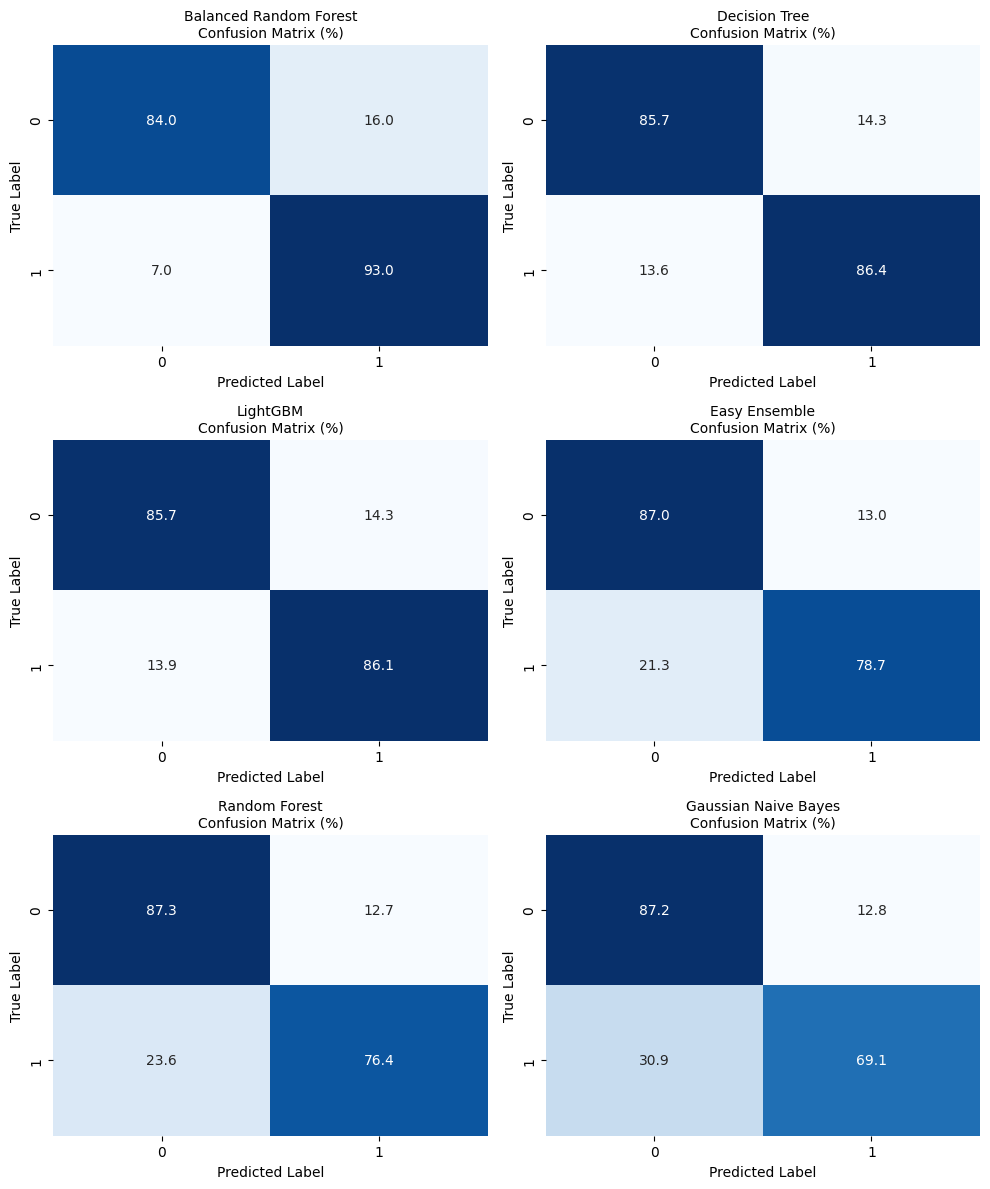

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get top 6 models
top_models = final_df.head(6).index
models_to_plot = []

# Prepare models and predictions
for model_name in top_models:
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            model.fit(X_train_small, y_train_small)
            y_pred = model.predict(X_test_small)
            models_to_plot.append((model_name, y_pred))
            break

# Plot 2 confusion matrices per row
n_cols = 2
n_rows = (len(models_to_plot) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

for idx, (model_name, y_pred) in enumerate(models_to_plot):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]  # handle 1-row case

    cm = confusion_matrix(y_test_small, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_perc, annot=True, fmt=".1f", cmap='Blues',
                xticklabels=np.unique(y_test_small),
                yticklabels=np.unique(y_test_small),
                ax=ax, cbar=False)

    ax.set_title(f"{model_name}\nConfusion Matrix (%)", fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Hide any empty subplots if odd number
if len(models_to_plot) % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

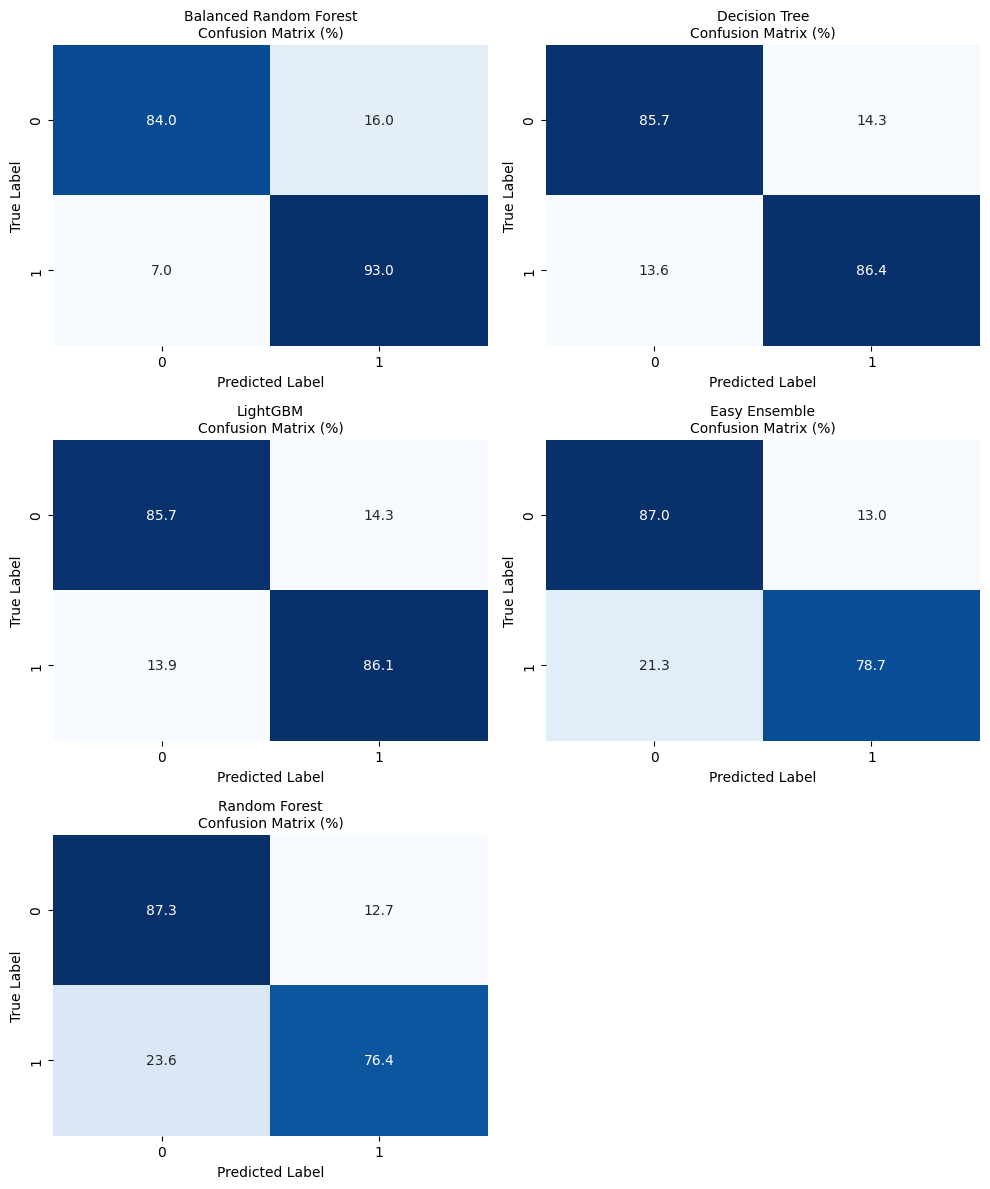

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get top 5 models
top_models = final_df.head(5).index
models_to_plot = []

# Prepare models and predictions
for model_name in top_models:
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            model.fit(X_train_small, y_train_small)
            y_pred = model.predict(X_test_small)
            models_to_plot.append((model_name, y_pred))
            break

# Plot 2 confusion matrices per row
n_cols = 2
n_rows = (len(models_to_plot) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

for idx, (model_name, y_pred) in enumerate(models_to_plot):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]  # handle 1-row case

    cm = confusion_matrix(y_test_small, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_perc, annot=True, fmt=".1f", cmap='Blues',
                xticklabels=np.unique(y_test_small),
                yticklabels=np.unique(y_test_small),
                ax=ax, cbar=False)

    ax.set_title(f"{model_name}\nConfusion Matrix (%)", fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Hide any empty subplots if odd number
if len(models_to_plot) % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.tight_layout()
plt.show()

Test Set Evaluation Summary:
                        Accuracy  Precision    Recall  F1-Score
Dummy Classifier        0.770819   0.594162  0.770819  0.671059
Logistic Regression     0.808231   0.790808  0.808231  0.792167
Decision Tree           0.858911   0.883474  0.858911  0.865456
Random Forest           0.847783   0.860289  0.847783  0.852208
KNN                     0.803203   0.782254  0.803203  0.777640
Gaussian Naive Bayes    0.830878   0.838779  0.830878  0.834125
Gradient Boosting       0.826777   0.820098  0.826777  0.822607
XGBoost                 0.826313   0.819203  0.826313  0.821803
LightGBM                0.858376   0.882706  0.858376  0.864904
Extra Trees             0.811905   0.794878  0.811905  0.794724
Balanced Random Forest  0.860337   0.897220  0.860337  0.868372
Easy Ensemble           0.851279   0.866043  0.851279  0.856191


<Figure size 1200x600 with 0 Axes>

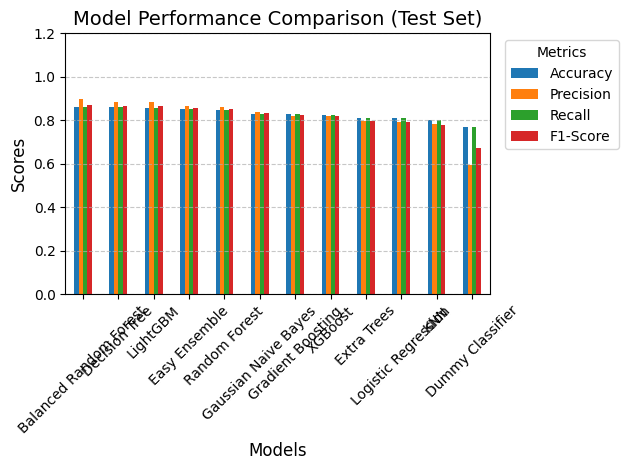

In [5]:
# Convert final test results to DataFrame
final_df = pd.DataFrame(final_test_results).T
final_df = final_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]  # Reorder for consistency

# Save to CSV
final_df.to_csv("final_test_metrics_all_models.csv")

# Print summary
print("Test Set Evaluation Summary:")
print(final_df)

# Sort models by F1-Score for better visual comparison
final_df_sorted = final_df.sort_values(by='F1-Score', ascending=False)

# Plot grouped bar chart of test set performance
plt.figure(figsize=(12, 6))
ax = final_df_sorted.plot(kind='bar')

# Customize bar chart appearance
plt.title('Model Performance Comparison (Test Set)', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left')  # Legend outside the plot
plt.tight_layout()
plt.savefig("model_test_performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Convert the final test results into a clean DataFrame
test_results_list = []

# Loop through all final test results
for model_name, metrics in final_df.iterrows():
    row = {
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"]
    }
    test_results_list.append(row)

# Create DataFrame and sort by F1-Score
test_results_df = pd.DataFrame(test_results_list)
test_results_df = test_results_df.sort_values(by="F1-Score", ascending=False)
test_results_df["Rank"] = test_results_df["F1-Score"].rank(ascending=False).astype(int)

# Reset index
test_results_df.reset_index(drop=True, inplace=True)

# Round for readability
test_results_df[["Accuracy", "F1-Score", "Precision", "Recall"]] = test_results_df[
    ["Accuracy", "F1-Score", "Precision", "Recall"]
].round(3)

# Display nicely
from IPython.display import display
display(test_results_df)

# Save to CSV
test_results_df.to_csv("sorted_test_model_performance.csv", index=False)

,Model,Accuracy,F1-Score,Precision,Recall,Rank
0,Balanced Random Forest,0.860,0.868,0.897,0.860,1
1,Decision Tree,0.859,0.865,0.883,0.859,2
2,LightGBM,0.858,0.865,0.883,0.858,3
3,Easy Ensemble,0.851,0.856,0.866,0.851,4
4,Random Forest,0.848,0.852,0.860,0.848,5
5,Gaussian Naive Bayes,0.831,0.834,0.839,0.831,6
6,Gradient Boosting,0.827,0.823,0.820,0.827,7
7,XGBoost,0.826,0.822,0.819,0.826,8
8,Extra Trees,0.812,0.795,0.795,0.812,9
9,Logistic Regression,0.808,0.792,0.791,0.808,10


In [7]:
!pip install seaborn
import seaborn as sns

,Model,Accuracy,F1-Score,Precision,Recall,Rank
0,Balanced Random Forest,0.860,0.868,0.897,0.860,1
1,Decision Tree,0.859,0.865,0.883,0.859,2
2,LightGBM,0.858,0.865,0.883,0.858,3
3,Easy Ensemble,0.851,0.856,0.866,0.851,4
4,Random Forest,0.848,0.852,0.860,0.848,5


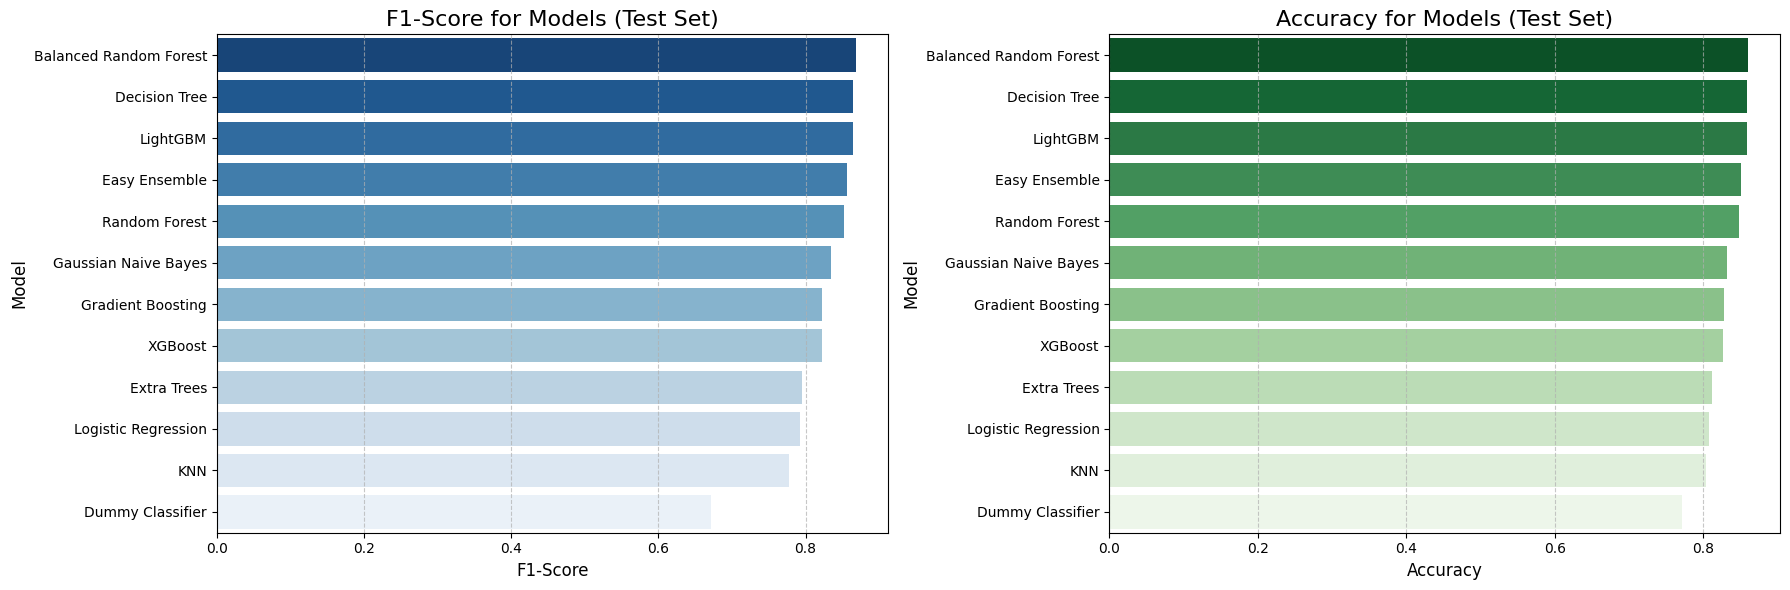

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Optional: Preview the DataFrame before plotting
display(test_results_df.head())

# Sort by F1-Score and Accuracy for clean plots
f1_sorted_df = test_results_df.sort_values(by="F1-Score", ascending=False)
acc_sorted_df = test_results_df.sort_values(by="Accuracy", ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# F1-Score Bar Plot
sns.barplot(
    data=f1_sorted_df,
    x="F1-Score",
    y="Model",
    hue="Model",
    palette="Blues_r",
    dodge=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("F1-Score for Models (Test Set)", fontsize=16)
axes[0].set_xlabel('F1-Score', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Accuracy Bar Plot
sns.barplot(
    data=acc_sorted_df,
    x='Accuracy',
    y='Model',
    hue='Model',
    palette="Greens_r",
    dodge=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Accuracy for Models (Test Set)", fontsize=16)
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# Final layout and save
plt.tight_layout()
plt.savefig("f1_accuracy_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## 15. Defining Imbalance Handling Techniques (Over-, Under-, and Hybrid Sampling)

In [10]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import (
    RandomUnderSampler, TomekLinks, ClusterCentroids, NearMiss,
    EditedNearestNeighbours, CondensedNearestNeighbour,
    OneSidedSelection, NeighbourhoodCleaningRule
)
from imblearn.combine import SMOTETomek, SMOTEENN

neighbors = 3  # SMOTE and similar methods need this

imbalance_methods = {
    "Original Data": None,
    f"SMOTE (k={neighbors})": SMOTE(random_state=42, k_neighbors=neighbors),
    f"ADASYN (k={neighbors})": ADASYN(random_state=42, n_neighbors=neighbors),
    f"Borderline-SMOTE (k={neighbors})": BorderlineSMOTE(random_state=42, k_neighbors=neighbors),
    "Random Oversampling": RandomOverSampler(random_state=42),

    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "NearMiss": NearMiss(version=1),
    "Cluster Centroids": ClusterCentroids(random_state=42),
    "Edited Nearest Neighbours": EditedNearestNeighbours(n_neighbors=3),
    #"Condensed Nearest Neighbour": CondensedNearestNeighbour(random_state=42),
    #"One-Sided Selection": OneSidedSelection(random_state=42),
    #"Neighbourhood Cleaning Rule": NeighbourhoodCleaningRule(n_neighbors=3),

    #"SMOTETomek": SMOTETomek(random_state=42),
    #"SMOTEENN": SMOTEENN(random_state=42),
}

## 16. Model Evaluation After Imbalance Handling (on Subsampled Data)

In [ ]:
imbalance_results = {}

# Set the pre-sampling ratio (how much of original X_train to use)
pre_sample_ratio = 0.2  # 20% of original training data

# Subsample once from original training data
X_train_subset, _, y_train_subset, _ = train_test_split(
    X_train, y_train, train_size=pre_sample_ratio, stratify=y_train, random_state=42
)

for method_name, sampler in imbalance_methods.items():
    print(f"\n Applying: {method_name}")

    # 1. Apply imbalance handling on the subset only
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X_train_subset, y_train_subset)
    else:
        X_resampled, y_resampled = X_train_subset.copy(), y_train_subset.copy()

    # 2. Subsample (again) for evaluation (optional if needed smaller)
    eval_sample_ratio = 0.5  # use 50% of resampled subset for CV to save more time
    X_resampled_small, _, y_resampled_small, _ = train_test_split(
        X_resampled, y_resampled, train_size=eval_sample_ratio, stratify=y_resampled, random_state=42
    )

    # 3. Evaluate models using CV on resampled small data
    method_results = []
    for i, group in enumerate(all_groups, 1):
        print(f"  → Evaluating group {i} models...")
        result = evaluate_models(group, X_resampled_small, y_resampled_small, skf, scoring)
        result.to_csv(f"resampled_{method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}_group{i}.csv")
        method_results.append(result)

    # 4. Combine and store results
    combined = pd.concat(method_results)
    imbalance_results[method_name] = combined
    combined.to_csv(f"resampled_results_{method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.csv")


 Applying: Original Data
  → Evaluating group 1 models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
  → Evaluating group 2 models...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
  → Evaluating group 3 models...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
  → Evaluating group 4 models...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

 Applying: SMOTE (k=3)
  → Evaluating group 1 models...
Evaluating Dummy Classifier...
Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
  → Evaluating group 2 models...
Evaluating KNN...
Evaluating Gaussian Naive Bayes...
  → Evaluating group 3 models...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
  → Evaluating group 4 models...
Evaluating Extra Trees...
Evaluating Balanced Random Forest...
Evaluating Easy Ensemble...

 

In [13]:
# Convert all imbalance_results into a unified DataFrame
summary_list = []

for method_name, df in imbalance_results.items():
    for model_name, metrics in df.iterrows():
        summary_list.append({
            "Imbalance Technique": method_name,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "F1-Score": metrics["F1-Score"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"]
        })

# Create DataFrame
imbalance_summary_df = pd.DataFrame(summary_list)

# Sort for readability
imbalance_summary_df = imbalance_summary_df.sort_values(by=["Imbalance Technique", "F1-Score"], ascending=[True, False])
imbalance_summary_df.reset_index(drop=True, inplace=True)

# Save and display
imbalance_summary_df.to_csv("imbalance_technique_model_summary.csv", index=False)
from IPython.display import display
display(imbalance_summary_df)

,Imbalance Technique,Model,Accuracy,F1-Score,Precision,Recall
0,ADASYN (k=3),LightGBM,0.893789,0.893611,0.898632,0.893789
1,ADASYN (k=3),Random Forest,0.874781,0.874708,0.877148,0.874781
2,ADASYN (k=3),Balanced Random Forest,0.874473,0.874387,0.877057,0.874473
3,ADASYN (k=3),KNN,0.859574,0.859491,0.859826,0.859574
4,ADASYN (k=3),Decision Tree,0.858295,0.858284,0.859127,0.858295
...,...,...,...,...,...,...
115,Tomek Links,XGBoost,0.840200,0.836712,0.834793,0.840200
116,Tomek Links,Extra Trees,0.822723,0.809909,0.810215,0.822723
117,Tomek Links,Logistic Regression,0.817429,0.803384,0.803670,0.817429
118,Tomek Links,KNN,0.805338,0.776108,0.789494,0.805338


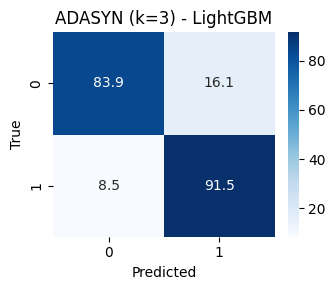

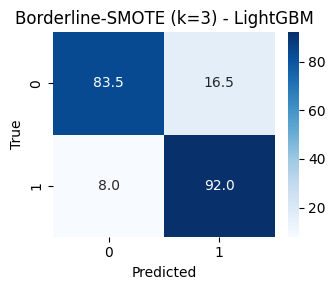

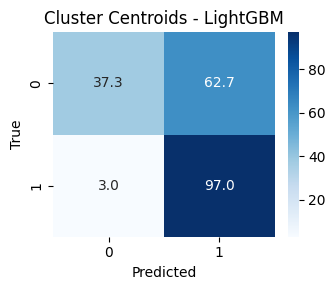

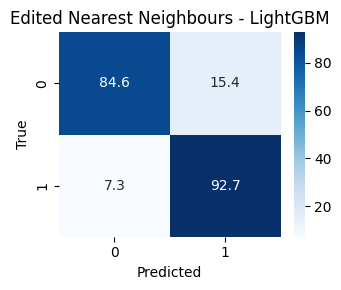

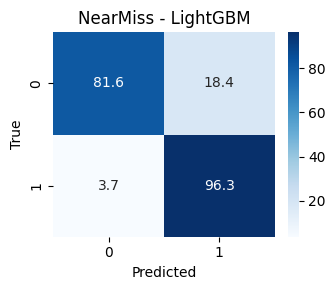

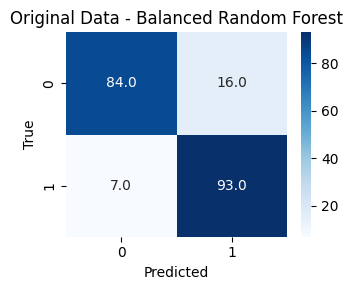

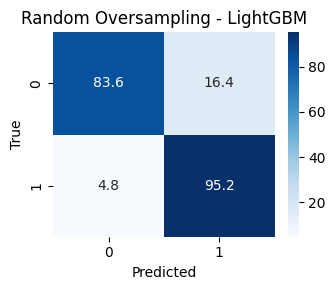

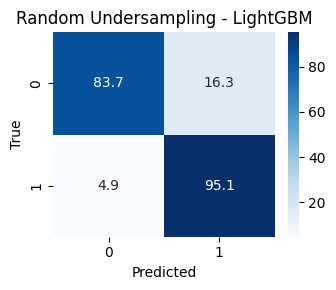

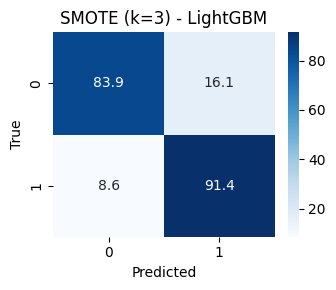

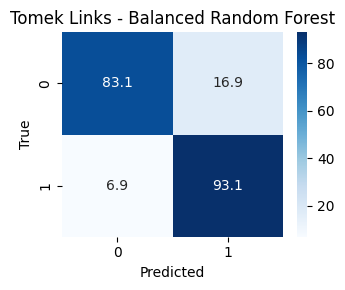

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

top_models_per_technique = imbalance_summary_df.groupby("Imbalance Technique").first().reset_index()

for _, row in top_models_per_technique.iterrows():
    technique = row["Imbalance Technique"]
    model_name = row["Model"]

    # Find the model
    for group in all_groups:
        if model_name in group:
            model = group[model_name]
            break

    # Get the resampled training set for that technique
    if technique == "Original Data":
        X_resampled, y_resampled = X_train_subset.copy(), y_train_subset.copy()
    else:
        sampler = imbalance_methods[technique]
        X_resampled, y_resampled = sampler.fit_resample(X_train_subset, y_train_subset)

    # Train and predict
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_test_small)

    # Confusion matrix
    cm = confusion_matrix(y_test_small, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Percent

    # Plot
    plt.figure(figsize=(3.5, 3))
    sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=np.unique(y_test_small),
                yticklabels=np.unique(y_test_small))
    plt.title(f"{technique} - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

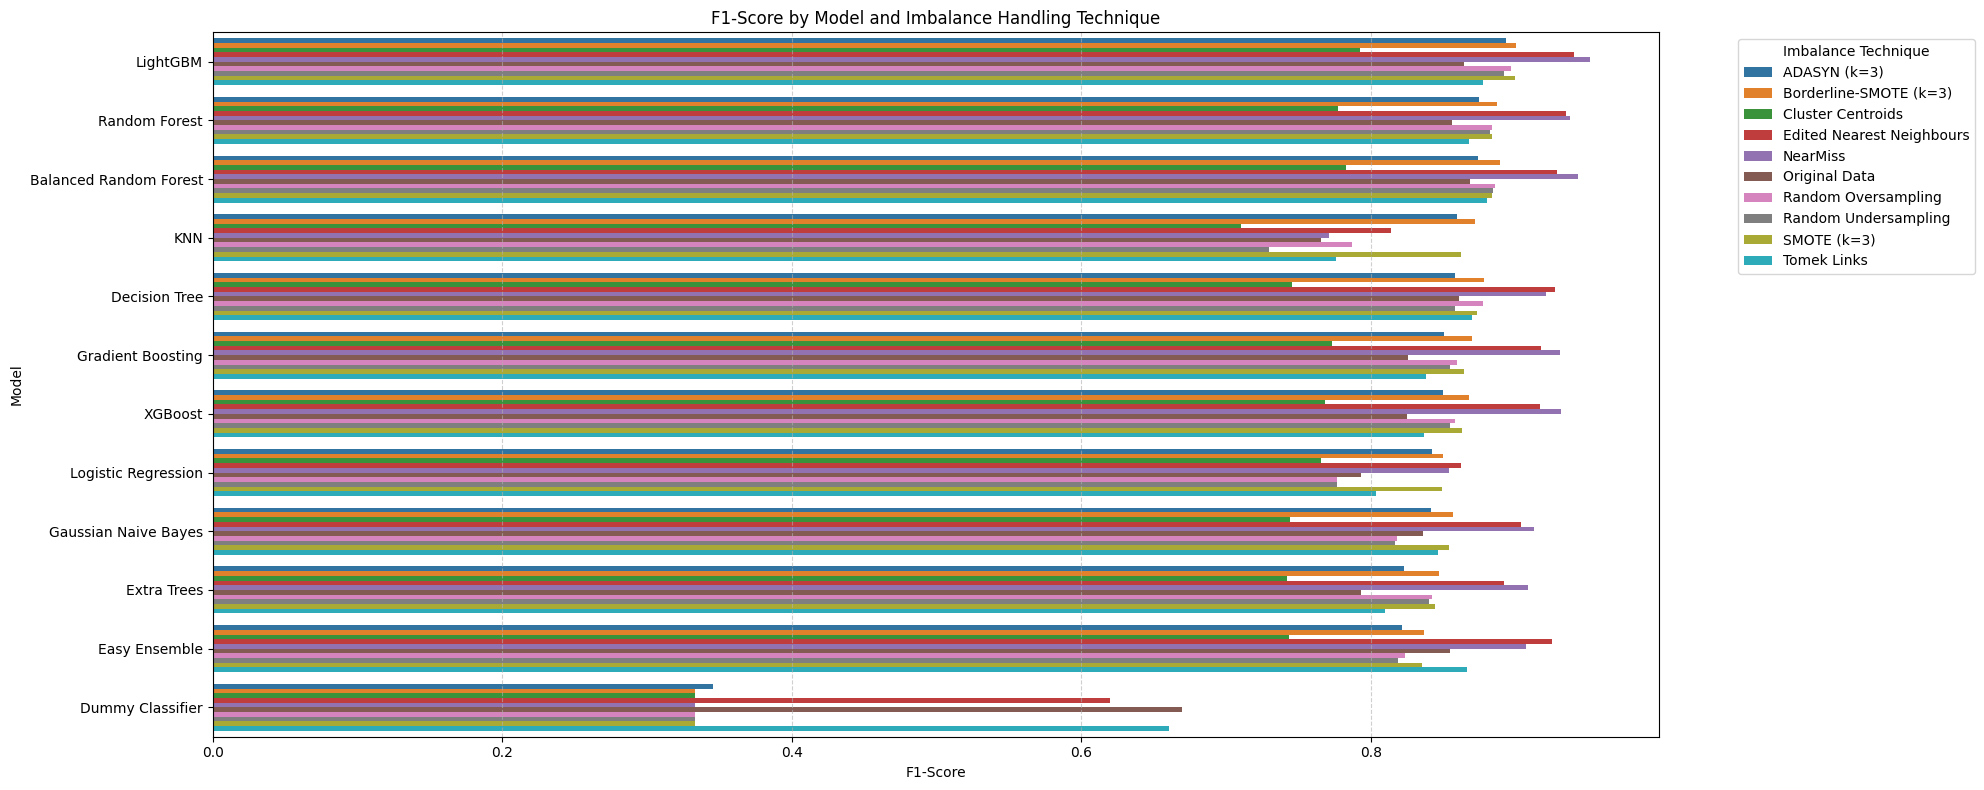

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.barplot(data=imbalance_summary_df, x="F1-Score", y="Model", hue="Imbalance Technique", dodge=True)
plt.title("F1-Score by Model and Imbalance Handling Technique")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.legend(title="Imbalance Technique", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("imbalance_techniques_model_comparison.png", dpi=300)
plt.show()

In [16]:
top_combo = imbalance_summary_df.sort_values(by="F1-Score", ascending=False).head(10)
display(top_combo)

,Imbalance Technique,Model,Accuracy,F1-Score,Precision,Recall
48,NearMiss,LightGBM,0.951601,0.951596,0.951790,0.951601
49,NearMiss,Balanced Random Forest,0.943431,0.943429,0.943492,0.943431
36,Edited Nearest Neighbours,LightGBM,0.939718,0.940244,0.941306,0.939718
50,NearMiss,Random Forest,0.937546,0.937544,0.937592,0.937546
37,Edited Nearest Neighbours,Random Forest,0.934964,0.935173,0.935451,0.934964
51,NearMiss,XGBoost,0.931428,0.931390,0.932382,0.931428
52,NearMiss,Gradient Boosting,0.930925,0.930887,0.931867,0.930925
38,Edited Nearest Neighbours,Balanced Random Forest,0.926777,0.928497,0.934693,0.926777
39,Edited Nearest Neighbours,Decision Tree,0.927501,0.927452,0.927420,0.927501
40,Edited Nearest Neighbours,Easy Ensemble,0.925806,0.925254,0.925053,0.925806
